In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 統計値を Simulation してみよう

「二年分の Data から一ヶ月分の Data を抽出する」という Simulation を行なう。

平均: -0.06374051192729041
標準偏差: 1.0005871669670903


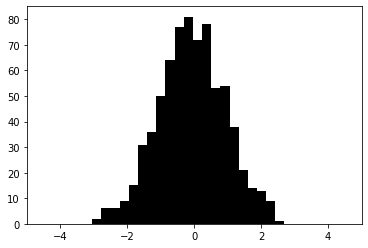

In [7]:
# 正規分布を生成する

# 母集合の大きさを設定
num = 365 * 2  # 「二年間」に相当する

# 乱数の平均・標準偏差を設定
ave = 0.0
std = 1.0

# 乱数の発生（Seed を固定)
np.random.seed(seed=0)
x = np.random.normal(ave, std, num)
# x = np.random.exponential(0.5, num)

# 平均・標準偏差を計算
x_ave = np.average(x)
x_std = np.std(x)
print('平均:', x_ave)
print('標準偏差:', x_std)

# 描画
num_bin = 21  # Bin幅を設定
plt.hist(x, num_bin, color='k')
plt.xlim([-5, 5])  # x軸の範囲を -5 ~ 5 に設定
plt.show()

先ほど作成した分布を母集団として、その中から「一ヶ月間」に相当する 30 の Data を Random に抽出（Random Sampling）し「標本集合」を作成。
作成した標本集合の平均値を計算する。その「平均値がどれほどばらつくか」を知るために Random Sampling を 10,000回行ない、その分布を Histogram に描画する。

平均: -0.06615481086793111
標準偏差: 0.18213372323603286


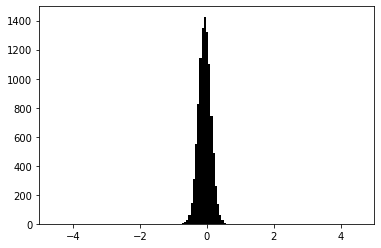

In [8]:
# Random Sampling した標本の平均の分布を描画する

# Sample数（Sample集団の大きさ）を設定
num_sample = 30  # 「一ヶ月」に相当

# 試行回数を設定
num_trial = 10_000  # Random Sampling の試行回数
x_trial = np.zeros(num_trial)

# Sample平均の算出を試行
for i in range(num_trial):
    # Sample を抽出
    x_sample = np.random.choice(x, num_sample)
    # 平均を計算
    x_ave = np.average(x_sample)
    # 値を格納
    x_trial[i] = x_ave

# Sample平均の平均・標準偏差を計算
x_trial_ave = np.average(x_trial)
x_trial_std = np.std(x_trial)
print('平均:', x_trial_ave)
print('標準偏差:', x_trial_std)

# 描画
num_bin = 21  # Bin幅の設定
plt.hist(x_trial, num_bin, color='k')  # Histogram を設定
plt.xlim([-5, 5])  # x軸の範囲を -5 ~ 5 に設定
plt.show()

Random Sampling の平均値のばらつきは
- 平均値: 約-0.066
- 標準偏差: 約0.18

標本平均の平均は、ほぼ 0 つまり母集団の平均値とほぼ同じで、標準偏差は母集団の標準偏差に比べて小さそうである。

In [9]:
-0.06374051192729041 - x_trial_ave

0.0024142989406406995

このばらつきが Random Sampling によって計算できる平均値がどれほどばらついているかを示す指標になる。
- Random Sampling の平均値が、標準偏差としてほぼ 0: 30日間の Data によって計算される平均値をはじめとする値は十分に信頼性のある値。
- Random Sampling の平均値が、標準偏差としてばらつきが大きい: 計算された値には信頼性が少なく、遥かに多くの Data数が必要。

### 母集団の標準偏差を大きくした場合にどうなるのか Simulation する

平均: -0.12748102385458082
標準偏差: 2.0011743339341805


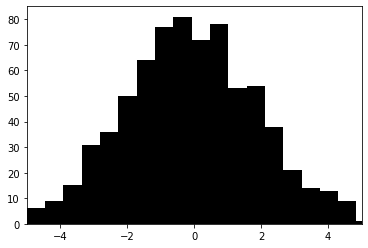

In [10]:
# 母集団の平均を 0.0 のままにして標準偏差を 2.0 にしてみる

# 母集合の大きさを設定
num = 365 * 2  # 「二年間」に相当する

# 乱数の平均・標準偏差を設定
ave = 0.0
std = 2.0

# 乱数の発生（Seed を固定)
np.random.seed(seed=0)
x = np.random.normal(ave, std, num)
# x = np.random.exponential(0.5, num)

# 平均・標準偏差を計算
x_ave = np.average(x)
x_std = np.std(x)
print('平均:', x_ave)
print('標準偏差:', x_std)

# 描画
num_bin = 21  # Bin幅を設定
plt.hist(x, num_bin, color='k')
plt.xlim([-5, 5])  # x軸の範囲を -5 ~ 5 に設定
plt.show()

平均: -0.13230962173586222
標準偏差: 0.3642674464720657


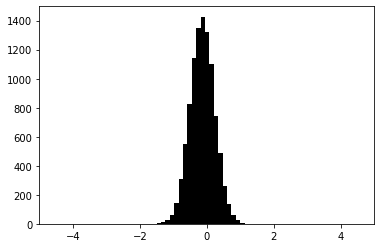

In [11]:
# Random Sampling した標本の平均の分布を描画する

# Sample数（Sample集団の大きさ）を設定
num_sample = 30  # 「一ヶ月」に相当

# 試行回数を設定
num_trial = 10_000  # Random Sampling の試行回数
x_trial = np.zeros(num_trial)

# Sample平均の算出を試行
for i in range(num_trial):
    # Sample を抽出
    x_sample = np.random.choice(x, num_sample)
    # 平均を計算
    x_ave = np.average(x_sample)
    # 値を格納
    x_trial[i] = x_ave

# Sample平均の平均・標準偏差を計算
x_trial_ave = np.average(x_trial)
x_trial_std = np.std(x_trial)
print('平均:', x_trial_ave)
print('標準偏差:', x_trial_std)

# 描画
num_bin = 21  # Bin幅の設定
plt.hist(x_trial, num_bin, color='k')  # Histogram を設定
plt.xlim([-5, 5])  # x軸の範囲を -5 ~ 5 に設定
plt.show()

標準偏差が元の２倍近くになっている。

Sample集合の平均値の標準偏差は、元の標準偏差に比例することが知られている。

### 母集団が正規分布に従わない場合の Simulation

平均: 0.5029448272198032
標準偏差: 0.5187224027106567


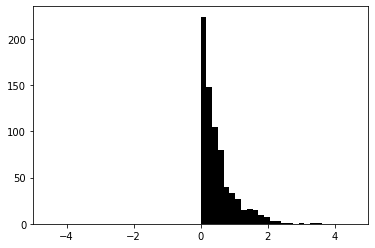

In [13]:
# べき分布を生成する

# 母集合の大きさを設定
num = 365 * 2  # 「二年間」に相当する

# 乱数の平均・標準偏差を設定
ave = 0.0
std = 1.0

# 乱数の発生（Seed を固定)
np.random.seed(seed=0)
# x = np.random.normal(ave, std, num)
x = np.random.exponential(0.5, num)  # べん分布に従う乱数を発生させる

# 平均・標準偏差を計算
x_ave = np.average(x)
x_std = np.std(x)
print('平均:', x_ave)
print('標準偏差:', x_std)

# 描画
num_bin = 21  # Bin幅を設定
plt.hist(x, num_bin, color='k')
plt.xlim([-5, 5])  # x軸の範囲を -5 ~ 5 に設定
plt.show()

平均: 0.5037628820216644
標準偏差: 0.09639007671292096


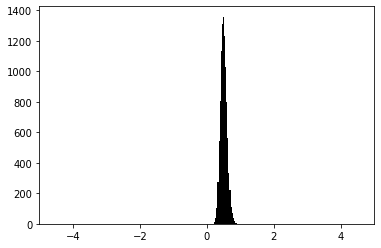

In [14]:
# Random Sampling した標本の平均の分布を描画する

# Sample数（Sample集団の大きさ）を設定
num_sample = 30  # 「一ヶ月」に相当

# 試行回数を設定
num_trial = 10_000  # Random Sampling の試行回数
x_trial = np.zeros(num_trial)

# Sample平均の算出を試行
for i in range(num_trial):
    # Sample を抽出
    x_sample = np.random.choice(x, num_sample)
    # 平均を計算
    x_ave = np.average(x_sample)
    # 値を格納
    x_trial[i] = x_ave

# Sample平均の平均・標準偏差を計算
x_trial_ave = np.average(x_trial)
x_trial_std = np.std(x_trial)
print('平均:', x_trial_ave)
print('標準偏差:', x_trial_std)

# 描画
num_bin = 21  # Bin幅の設定
plt.hist(x_trial, num_bin, color='k')  # Histogram を設定
plt.xlim([-5, 5])  # x軸の範囲を -5 ~ 5 に設定
plt.show()

母集団はべき分布に従っているにもかかわらず、標本集合の平均値の分布は、 **正規分布のような分布に従っているように見える** 。

=> 「中心極限定理」と呼ばれる定理の意味するところ

## 中心極限定理について知ろう
乱数を発生させてその中から Random Sampling を行なう Simulation から分かったこと
- 標本集合の平均は、母集合の平均に近いように見える
- 母集合の標準偏差を２倍にすると、標本集合の平均値の標準偏差もまた２倍近くに見える
- 母集合が正規分布に従っていなくとも、標本集合の平均値は正規分布に従うように見える

### 大数の法則
母集合の Size（Data数）が十分に大きく、標本集合の Size（Data数）もまた十分に大きな場合には、標本集合の平均値は母集合の平均値に近づくこと

### 中心極限定理
大数の法則から導かれるもの
母集合が平均 μ、標準偏差 σ に従う場合、標本平均は
- 平均: μ
- 標準偏差: σ / np.sqrt(n)

の正規分布に従う（n は標本集合の Size）

In [18]:
# 中心極限定理を用いて標本集合の標準偏差を求める

# 母集合の分散を設定
org_std = 1.0

# Sample の大きさを設定
num_sample = 30

# Sample集合の平均の標準偏差を計算
sample_std = org_std/np.sqrt(num_sample)

print('Sample集合の平均の標準偏差:', sample_std)

Sample集合の平均の標準偏差: 0.18257418583505536


## １ケ月の Data を正確に取ってみよう
Hotel の Data を用いながら、盗難被害の状況について分析していく

In [21]:
# １ケ月分の被害List を読み込む
df_theft_201811 = pd.read_csv('data/Chapter3/theft_list_201811.csv', index_col=0, parse_dates=[0])

df_theft_201811

,バスタオル,ハンドタオル,フェイスタオル,バスローブ,ハンガー,ボールペン,ナイフ,フォーク,スプーン,皿,...,クッション,リモコン,パソコン,ドライヤー,アイロン,カフェマシーン,照明,電話,テレビ,マット
日時,,,,,,,,,,,,,,,,,,,,,
2018-11-01,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-11-02,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-11-03,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-11-04,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2018-11-05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-11-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-11-07,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-11-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-11-09,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Amenity の金額List を読み込む
df_amenity_price = pd.read_csv('data/Chapter3/amenity_price.csv', index_col=0, parse_dates=[0])

df_amenity_price

,金額
バスタオル,2000
ハンドタオル,1500
フェイスタオル,1200
バスローブ,10000
ハンガー,500
ボールペン,1000
ナイフ,500
フォーク,500
スプーン,500
皿,2000


In [24]:
# １ヶ月分の被害List から被害総額を計算する
total_amount = 0
total_theft = 0
for i_index in range(len(df_theft_201811.index)):
    for i_column in range(len(df_theft_201811.columns)):
        # 被害金額を足しんでいく
        total_amount += df_theft_201811.iloc[i_index, i_column]*df_amenity_price['金額'].iloc[i_column]
        # 被害件数を足しこんでいく
        total_theft += df_theft_201811.iloc[i_index, i_column]
        # 被害の詳細を順次表示
        if df_theft_201811.iloc[i_index, i_column]>0:
            print(df_theft_201811.index[i_index], df_theft_201811.columns[i_column], df_theft_201811.iloc[i_index, i_column], '点')

print('被害総額:', total_amount, '円')
print('被害件数:', total_theft, '件')

2018-11-01 00:00:00 バスタオル 1.0 点
2018-11-01 00:00:00 ハンドタオル 1.0 点
2018-11-01 00:00:00 カップ 1.0 点
2018-11-02 00:00:00 バスタオル 1.0 点
2018-11-03 00:00:00 ハンガー 1.0 点
2018-11-03 00:00:00 フォーク 2.0 点
2018-11-04 00:00:00 バスタオル 1.0 点
2018-11-04 00:00:00 グラス 1.0 点
2018-11-04 00:00:00 テレビ 1.0 点
2018-11-05 00:00:00 フェイスタオル 1.0 点
2018-11-06 00:00:00 カップ 1.0 点
2018-11-07 00:00:00 フェイスタオル 1.0 点
2018-11-09 00:00:00 フェイスタオル 1.0 点
2018-11-10 00:00:00 バスタオル 1.0 点
2018-11-10 00:00:00 ハンドタオル 1.0 点
2018-11-11 00:00:00 バスタオル 1.0 点
2018-11-11 00:00:00 フェイスタオル 1.0 点
2018-11-11 00:00:00 コスメ用品 1.0 点
2018-11-12 00:00:00 ボールペン 1.0 点
2018-11-12 00:00:00 ナイフ 1.0 点
2018-11-12 00:00:00 スプーン 1.0 点
2018-11-13 00:00:00 バスタオル 1.0 点
2018-11-13 00:00:00 フェイスタオル 1.0 点
2018-11-14 00:00:00 バスタオル 1.0 点
2018-11-14 00:00:00 ハンドタオル 1.0 点
2018-11-14 00:00:00 ハンガー 1.0 点
2018-11-14 00:00:00 フォーク 1.0 点
2018-11-15 00:00:00 バスタオル 1.0 点
2018-11-15 00:00:00 ボールペン 1.0 点
2018-11-16 00:00:00 フェイスタオル 1.0 点
2018-11-16 00:00:00 ボールペン 1.0 点
2018-11-

#### 2022年11月の被害状況
- 被害総額: 177,900円
- 被害件数: 70.0件

１日２件以上の被害が発生しており、その総額も決して少なくないことを確認。

この数字にどの程度ばらつきがあるのか前もって知っておくことができれば、１年間や２年間の被害総額を概算として見積もることができ対策につなげることができる。